In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("dano_dataset_travel.csv", "r", encoding="utf-8") as f:
    for i in range(2):
        print(f.readline())

order_online_payment_flg;account_rk;client_rk;order_rk;loyalty_program_type_nm;bundle_nm;order_type_cd;order_status_cd;party_first_order_dt;party_first_order_type_dt;free_cancel_booking_dttm;created_dttm;cancel_dttm;book_start_dttm;local_book_start_dttm;book_end_dttm;hotel_country;hotel_city;avia_dep_city;avia_arr_city;promo_code_discount_amt;loyalty_accrual_rub_amt;nominal_price_eur_amt;nominal_price_rub_amt;order_item_cnt;month_beginning_balance_rub;monthly_income_amt;suppress_email_flg;suppress_call_flg;bounce_cd;last_sms_success_flg;call_contact_6m_flg;call_contact_3m_flg;call_contact_1m_flg;good_email_address_flg;bad_email_address_flg;email_valid_flg;children_cnt;age;age_type_cd;parent_meeting_region_nm;delivery_region_category_cd;lvn_city_nm;lvn_state_nm;time_zone_delta_tm;time_zone_cd;last_used_product_cd;first_used_product_cd;mobile_phone_operator_nm;marital_status_cd;education_level_cd;birth_place;gender_cd;last_sms_dt;last_email_send_dt;last_session_dttm

1,0;209c833731e84d21

**Разделитель - ;**

In [3]:
df = pd.read_csv("dano_dataset_travel.csv", sep=';')

C:\Users\Petr\AppData\Local\Temp\ipykernel_18368\1195759353.py:1: DtypeWarning: Columns (31,32,33,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dano_dataset_travel.csv", sep=';')


# Беглый взгляд на данные

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

In [5]:
# Процент NaN
nan_percent = df.isna().mean() * 100
print(nan_percent.sort_values())

suppress_email_flg               0.000000
time_zone_cd                     0.000000
time_zone_delta_tm               0.000000
delivery_region_category_cd      0.000000
email_valid_flg                  0.000000
suppress_call_flg                0.000000
last_session_dttm                0.000000
order_rk                         0.000000
client_rk                        0.000000
account_rk                       0.000000
age                              0.000120
last_used_product_cd             0.000359
age_type_cd                      0.029667
mobile_phone_operator_nm         0.148336
last_sms_success_flg             0.239133
last_sms_dt                      0.239133
first_used_product_cd            0.294280
birth_place                      0.354691
gender_cd                        1.215042
book_start_dttm                  5.868019
order_type_cd                    5.868019
created_dttm                     5.868019
nominal_price_eur_amt            5.868019
nominal_price_rub_amt            5

In [6]:
# Количество уникальных значений (исключая NaN)
count_unique = df.nunique().sort_values()
print(len(count_unique))
count_unique

56


cancel_dttm                         0
order_online_payment_flg            1
call_contact_1m_flg                 1
call_contact_3m_flg                 1
call_contact_6m_flg                 1
gender_cd                           2
email_valid_flg                     2
bad_email_address_flg               2
good_email_address_flg              2
last_sms_success_flg                2
suppress_call_flg                   2
suppress_email_flg                  2
order_type_cd                       2
delivery_region_category_cd         3
age_type_cd                         4
last_used_product_cd                4
education_level_cd                  5
marital_status_cd                   6
order_status_cd                     7
children_cnt                        8
bundle_nm                           9
first_used_product_cd               9
order_item_cnt                      9
bounce_cd                          10
time_zone_delta_tm                 12
time_zone_cd                       23
loyalty_prog

In [7]:
df.sample(10).T

,325871,796455,343453,282259,238686,358940,395410,84832,504058,107403
order_online_payment_flg,"1,0","1,0","1,0",NaN,"1,0","1,0","1,0","1,0","1,0","1,0"
account_rk,3f2b4ad8dbbba247975c549c4d82b09bcb87493631086e...,5fabd5041d5dbdb22fea8ccac58bc4b98feef56c49470f...,70f6801de0ba95e19313052917f001e38e553ebbb7ff81...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,c0a89106c9b562203646f4af6c587c219c9f199b1d4b69...,915bd6bc8b3edec7a72a5f04fd61c31079d34535d6aefd...,fbb5b823b30ea9452a0f4fcdd86a7daded3cd80e29f5a3...,e1920e804cc1e0d921efcea1b2cda200ada66b08100b82...,5ae46bd420a700348be1c01aeedb88dd1c477d7cedd5c1...,a951b4b31c39fa0ac960c90b5c73f9bad00638c445049e...
client_rk,641645edceab250441b921951c89d22196b5d6ae823628...,6c4f343aedbf1356950a50b4326c8abe602c3f07a8dc94...,5bca62884d9640e4f5821a574697649fa98b24c01b169a...,8d20538b5f5a0e19eb326909cbc95a28889096b4b6beda...,e833789b6a1c76ac332cf336d64db13c7f4e1115d984ea...,16587fd08ecb830eb480ad91de27666695e6b4b0f2980d...,3c25e832c564338a56c4d2e4707c811c0a9254b978772b...,8d6bda16e4d9afa890bf735085e02ed075625142d45693...,58c15652592b8c37c53a55bd789c2393c97186230258a6...,87015d172a943e7d1d353963372bf6663822f5c63273b4...
order_rk,cac26d0307285c5e573ca434b70cc69898f17b80aba278...,f01d6df017d058695a83390994c780b4e77a3c87f96952...,7ae7a55073b50bfcf1307220a04de4aa1e9aa3d839c8c8...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,08f919f9746bfa4d9f3d1fc20eb3dc6fd74c154c9d4eeb...,ffcfc19ce72ce2b456390c160c2da9e32dc2431ef3b82e...,dfb903a5c0190223cedae293d0bb953664d3c803026870...,f92d6f628efeb3280eebdbee4ff59d00ccd54297ccfb8e...,4f11ce7ee7f6171c77450a86e86289d9578118534ba51d...,2b234fcc925a3e10322d8046a4b9b8c5d46b05e4910983...
loyalty_program_type_nm,Tinkoff Black,Tinkoff Black Private,Tinkoff Black Premium,NaN,All Airlines,Tinkoff Black,Tinkoff Black,Tinkoff Black,Tinkoff Black,Tinkoff Black
bundle_nm,NaN,Private,Premium,NaN,Pro,NaN,Pro,Pro,Pro,Pro
order_type_cd,AIR,AIR,AIR,NaN,HOT,AIR,AIR,AIR,HOT,AIR
order_status_cd,PRC,SUC,SUC,NaN,SUC,SUC,SUC,SUC,SUC,SUC
party_first_order_dt,2019-03-10,2020-11-11,2022-04-27,NaN,2019-02-23,2021-08-17,2023-08-17,2021-05-28,2024-05-14,2023-12-16
party_first_order_type_dt,2021-03-30,2020-11-17,2024-08-08,NaN,2024-01-09,2021-08-17,2023-08-17,2021-06-30,2024-05-14,2023-12-16


# Убираем пробельные символы по бокам и заменяем все текстовые аналоги NaN. Также создаём резрвную копию df, чтобы потом не пришлось заново читать её из файла

In [8]:
df_backup_copy = df.copy(deep=True)

In [9]:
df = df_backup_copy.copy(deep=True)

In [10]:
for col in df.columns: 
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)


list_str_nan = ["", " ", "-", "—", "NaN", "nan", "NULL", "None", "N/A"]
df.replace(list_str_nan, pd.NA, inplace=True)

# Приводим данные к нужным типам

 27  suppress_email_flg           835938 non-null  int64  
 28  suppress_call_flg            835938 non-null  int64  
 29  bounce_cd                    39675 non-null   object 
 30  last_sms_success_flg         833939 non-null  object 
 31  call_contact_6m_flg          271 non-null     object 
 32  call_contact_3m_flg          271 non-null     object 
 33  call_contact_1m_flg          271 non-null     object 
 34  good_email_address_flg       19798 non-null   object 
 35  bad_email_address_flg        19798 non-null   object 
 36  email_valid_flg              835938 non-null  int64      

In [11]:
num_cols = ["promo_code_discount_amt", "nominal_price_eur_amt", "loyalty_accrual_rub_amt", "nominal_price_rub_amt", "order_item_cnt", 
            "month_beginning_balance_rub", "monthly_income_amt", "children_cnt", "age", "time_zone_cd"]

for i in num_cols:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce")

In [12]:
date_cols = ["party_first_order_dt", "party_first_order_type_dt", "party_first_order_type_dt", "free_cancel_booking_dttm", "created_dttm",
             "book_start_dttm", "local_book_start_dttm", "book_end_dttm", "last_sms_dt", "last_email_send_dt", "last_session_dttm"]

for i in date_cols:
    df[i] = pd.to_datetime(df[i], errors="coerce")

In [13]:
date_fg = ["order_online_payment_flg", "last_sms_success_flg", "call_contact_6m_flg", "call_contact_3m_flg", "call_contact_1m_flg",
           "good_email_address_flg", "bad_email_address_flg"] # Исключая suppress_email_flg, suppress_call_flg и email_valid_flg (потому что они int)

for i in date_fg:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce").astype("Int64")

# Повторный беглый просмотр данных

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  Int64         
 1   account_rk                   835938 non-null  object        
 2   client_rk                    835938 non-null  object        
 3   order_rk                     835938 non-null  object        
 4   loyalty_program_type_nm      754957 non-null  object        
 5   bundle_nm                    588049 non-null  object        
 6   order_type_cd                786885 non-null  object        
 7   order_status_cd              779514 non-null  object        
 8   party_first_order_dt         786885 non-null  datetime64[ns]
 9   party_first_order_type_dt    786767 non-null  datetime64[ns]
 10  free_cancel_booking_dttm     75600 non-null   datetime64[ns]
 11  created_dttm              

In [15]:
df.sample(10).T

,692021,758958,17139,797514,291934,492833,125136,560884,761513,427578
order_online_payment_flg,1,1,1,1,1,1,1,1,1,1
account_rk,629c1febd0aab9617baa67b8f3f6eb512a266f5be2fe70...,fd3d4b931c188ddfcacd430eb12b7442e97aabd3c25c6a...,9b6f501c8b48d213b82dc33fa4c46d73c4d26307c1a3ca...,9a1f780f97c9bf0191a77b217204e8e1c796014f3bb84e...,3704e2246986cc4abe4deb9a3c95d018cc08fd56c71416...,21258115dd20d8311baf9f8bcb54d8f2b38214617830ac...,76509adbac1ec92d02e0912d2b6d97a9a190d45e187997...,aad6210cf614c57271895e749ed5d13f2fca920406102a...,5767faf4de873a7c243e140f23a547b5dce9b9a5a964ad...,5a80f9d69fdc237d015ab0987247ea7553b233dc8bf2c0...
client_rk,66ed417de5ef88bb28bd08eae5d11b42b7d71914d91cd7...,d2569a1c7f63ad364d0ce58b3b49dca59e0304f2ffb559...,a51241b1773a9e06e11fb5b20c9aee75184d1f891db8c0...,c8b1a5fd3a2407d573779e0f6deb9ff112923f54cb5b50...,cf5cc1af60f7dee8f1f07df96dba0088a5490d5106f5a4...,d72027bb15158f2dcb0f010843e9060d5aa59262fb8cb1...,7a4be4fae065a75a7d9f67ec312eaf5ea0a70b1b293f79...,3d441d2da425f7577133a89cbe0483e20048bd39acb4ef...,565a26a1492de22c68e0f075ac57985f9bf2d14acecd78...,4a5220ce9fbe94bd06fc5335b3498d4887970c7f0871b1...
order_rk,bfcc34128169dcb17cb5c6b17f2c2405efe3d676f309f0...,dfafbd907177dddffb0af470b409e2389ff785f4e312f5...,6b280fe830f40f584238bc39d705521af25b6a39fd0153...,2befa96bac0246c62969eb3f47894f36d21523cfd4646a...,729f89347f3ddc8a67d095baf97c268b2d7bfcdca3b2af...,4903f641c125ce883811fe6da15d89f7b8843d53865681...,9a69702b918b55fb2d45ada2324583e15b8f2e20d333a0...,73215741eaffac2a184ad2f7ebe621a42025719321f567...,bd68ef53a065a0b12ebe9a2bdce575044f4de37e1cc9fb...,37f5936d50a6e7e93a18f48fd91a3166ed5f4110c208ae...
loyalty_program_type_nm,Tinkoff Black Premium,Tinkoff Black,Tinkoff Black Premium,Tinkoff Black Premium,Tinkoff Black,All Airlines Premium Кредитный,Tinkoff Black,Tinkoff Black,All Airlines Premium Кредитный,Tinkoff Black
bundle_nm,Premium,Pro,Pro,Pro,NaN,Premium,Pro,Pro,Premium,Pro
order_type_cd,HOT,AIR,HOT,HOT,AIR,AIR,AIR,AIR,AIR,AIR
order_status_cd,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC
party_first_order_dt,2019-12-04 00:00:00,2022-06-16 00:00:00,2023-03-08 00:00:00,2019-10-10 00:00:00,2021-12-27 00:00:00,2018-08-21 00:00:00,2024-10-18 00:00:00,2021-05-13 00:00:00,2023-04-06 00:00:00,2024-01-07 00:00:00
party_first_order_type_dt,2022-05-04 00:00:00,2022-06-16 00:00:00,2024-07-19 00:00:00,2021-10-10 00:00:00,2021-12-27 00:00:00,2019-10-24 00:00:00,2024-10-18 00:00:00,2021-05-13 00:00:00,2023-04-06 00:00:00,2024-01-16 00:00:00


# Функция для быстрого просмотра столбца

1) Процент пустых записей: 9.687440934614768
2) Количество пустых записей: 80981
3) Количество уникальных записей: 36
4) Топ уникальных записей для loyalty_program_type_nm
Tinkoff Black                     289081
Tinkoff Black Premium             189005
All Airlines                      143114
NaN                                80981
Bravo                              41428
All Airlines Premium Кредитный     28634
All Airlines Premium               16277
AllAirLinesDebit                   14824
Tinkoff Black Private               6994
Tinkoff Platinum                    6154
Name: count, dtype: int64:
5) Количество типов записей: loyalty_program_type_nm
<class 'str'>      754957
<class 'float'>     80981
Name: count, dtype: int64


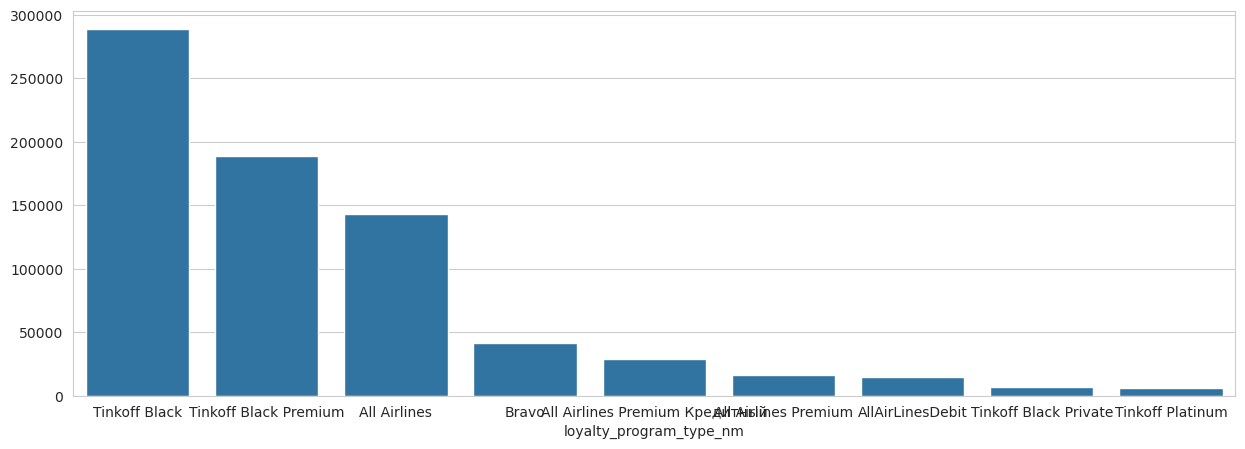

In [16]:
def my_analis(data_set, column, figsize=(10, 5)):
    nan_percent = data_set[column].isna().mean() * 100
    nan_count = data_set[column].isna().sum()
    count_unique = data_set[column].nunique()
    top_values = data_set[column].value_counts(dropna=False, ascending=False).head(count_unique if count_unique <= 10 else 10)
    types = data_set[column].apply(type).value_counts()
    print(f"1) Процент пустых записей: {nan_percent}")
    print(f"2) Количество пустых записей: {nan_count}")
    print(f"3) Количество уникальных записей: {count_unique}")
    print(f"4) Топ уникальных записей для {top_values}:")
    print(f"5) Количество типов записей: {types}")
    with sns.axes_style("whitegrid"):
        plt.figure(figsize=figsize)
        sns.barplot(
            y=top_values.values, 
            x=top_values.index)


my_analis(df, "loyalty_program_type_nm", (15, 5))

# Удаление мало заполненных столбцов и других ненужных столбцов. А также доработка данных.


**Процент незаполненных:**
- children_cnt                    13.905218
- monthly_income_amt              19.482306
- promo_code_discount_amt         26.322287
- order_item_cnt                  26.389637
- avia_dep_city                   26.397053
- avia_arr_city                   26.397053
- bundle_nm                       29.653993
- marital_status_cd               37.688202
- lvn_city_nm                     43.061686
- loyalty_accrual_rub_amt         43.135376
- education_level_cd              43.165163
- book_end_dttm                   79.478382
- hotel_city                      80.590905
- hotel_country                   80.590905
- free_cancel_booking_dttm        90.956267

**Нижнее - УДАЛЯЕМ (много пустых):**
- last_email_send_dt              97.631643
- bad_email_address_flg           97.631643
- good_email_address_flg          97.631643
- call_contact_3m_flg             99.967581
- call_contact_1m_flg             99.967581
- call_contact_6m_flg             99.967581
- cancel_dttm                    100.000000

**Другие столбцы для удаления (эти данные точно не буду сейчас использовать):**
- birth_place - Место рождения
- last_session_dttm - Дата последней сессии
- account_rk - Идентификатор счета
- local_book_start_dttm - Дата заезда в местном часовом поясе (для отелей)
- time_zone_cd - Код часового пояса
- time_zone_delta_tm - Разница часового пояса с Гринвичем

In [17]:
# Мало данных:
cols_to_drop = [
    "last_email_send_dt", "bad_email_address_flg", "good_email_address_flg", "call_contact_3m_flg", "call_contact_1m_flg", 
    "call_contact_6m_flg", "cancel_dttm"]

df2 = df.drop(columns=cols_to_drop)

In [18]:
# Эти данные точно не буду сейчас использовать
cols_to_drop = [
    "birth_place", "last_session_dttm", "account_rk", "local_book_start_dttm", "time_zone_cd", 
    "time_zone_delta_tm"]

df2 = df2.drop(columns=cols_to_drop)

1) Процент пустых записей: 95.25383461452883
2) Количество пустых записей: 796263
3) Количество уникальных записей: 10
4) Топ уникальных записей для bounce_cd
NaN     796263
5,0      25261
15,0      7693
17,0      5403
13,0       400
14,0       366
9,0        257
10,0       192
11,0        62
2,0         25
Name: count, dtype: int64:
5) Количество типов записей: bounce_cd
<class 'float'>    796263
<class 'str'>       39675
Name: count, dtype: int64


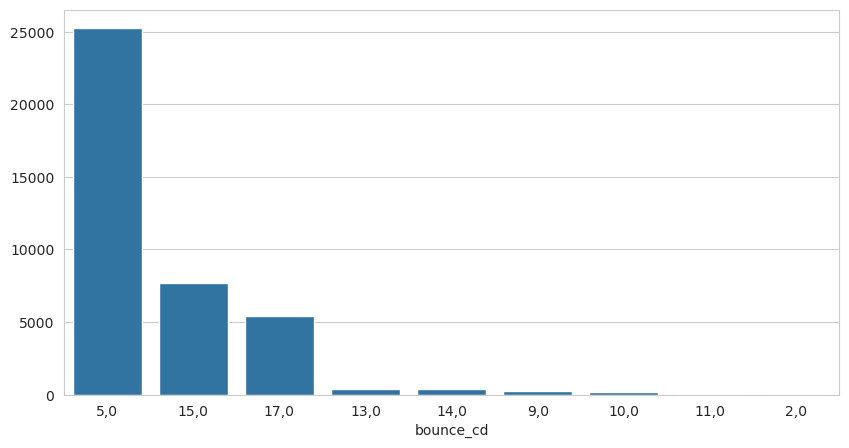

In [19]:
my_analis(df2, "bounce_cd")

bounce_cd - Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
Тогда заменяем NaN на 1 (доставлено), а остльные занчения на 0 (не доставлено)

In [20]:
df2["bounce_cd"] = df2["bounce_cd"].apply(lambda x: 1 if pd.isna(x) else 0)

In [21]:
nan_percent = df2.isna().mean() * 100
print(nan_percent.sort_values())

client_rk                       0.000000
order_rk                        0.000000
suppress_email_flg              0.000000
delivery_region_category_cd     0.000000
suppress_call_flg               0.000000
email_valid_flg                 0.000000
bounce_cd                       0.000000
age                             0.000120
last_used_product_cd            0.000359
age_type_cd                     0.029667
mobile_phone_operator_nm        0.148336
last_sms_dt                     0.239133
last_sms_success_flg            0.239133
first_used_product_cd           0.294280
gender_cd                       1.215042
nominal_price_rub_amt           5.868019
nominal_price_eur_amt           5.868019
order_online_payment_flg        5.868019
order_type_cd                   5.868019
book_start_dttm                 5.868019
created_dttm                    5.868019
party_first_order_dt            5.868019
party_first_order_type_dt       5.882135
parent_meeting_region_nm        5.919219
lvn_state_nm    

# Соотношение заказов авиабилетов и бронирования отеля

1) Процент пустых записей: 5.86801892006345
2) Количество пустых записей: 49053
3) Количество уникальных записей: 2
4) Топ уникальных записей для order_type_cd
AIR    615337
HOT    171548
Name: count, dtype: int64:
5) Количество типов записей: order_type_cd
<class 'str'>      786885
<class 'float'>     49053
Name: count, dtype: int64


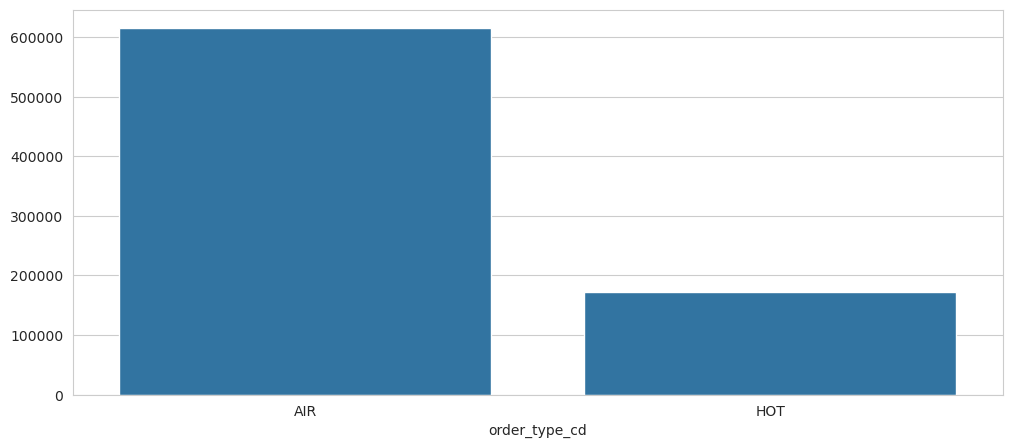

In [22]:
my_analis(df2, "order_type_cd", (12, 5))

# Доля клиентов в дата сете, совершивших покупку

In [23]:
clients_with_SUC = df2.loc[df2['order_status_cd'] == 'SUC']
clients_without_SUC = df2.loc[df2['order_status_cd'] != 'SUC',]

amount_all_clients = df2['client_rk'].nunique()
amount_clients_with_SUC = clients_with_SUC['client_rk'].nunique()


a = amount_clients_with_SUC / amount_all_clients

print(f"Уникальных клиентов всего: {amount_all_clients}")
print(f"Клиентов с покупкой (SUC): {amount_clients_with_SUC}")
print(f"Доля клиентов с покупкой: {a * 100}%")

Уникальных клиентов всего: 148364
Клиентов с покупкой (SUC): 99232
Доля клиентов с покупкой: 66.88414979375051%


1) Процент пустых записей: 0.0
2) Количество пустых записей: 0
3) Количество уникальных записей: 148364
4) Топ уникальных записей для client_rk
a46735f4d392f42bd73943c6330a2c69028e33c166a73e749f0ddedc741e793d    359
132bec81e337f879717537f80861b54cf42ffd3568ec6a676bea7df6242d4669    322
32b8241d743ce92cc5d9d4933b079b916235bfbcd1655c4104c6d2f6667ee3a9    285
7e261ba824f595a9883424fff670dba6de96e69d0da0129d7c8a1bd05bbca57c    274
fa4a935860d7c782101f0f0387566d12972a5952a4553198b95ca2135850a204    256
ce8310d3ae9d5c412e727cbf8d126c08c88f7a1b49aacd2b3c057d2dffbfab26    251
87c3b299c2d27f63e36b3b839958894fee556a366f422ffd9bb545843773da96    242
8c1c5f38cfd28edbed4e152639aa137137afb31b989d866714c95dc3c0cd9cfc    234
0a2baf20a44cb90a000ebb8c15c272864546127b22ef5114c78203755a237b64    228
94b16e5c3dd465d04652205ceebd9e797b0ee53a21c37cb2ba0d916ee835e98a    219
Name: count, dtype: int64:
5) Количество типов записей: client_rk
<class 'str'>    835938
Name: count, dtype: int64


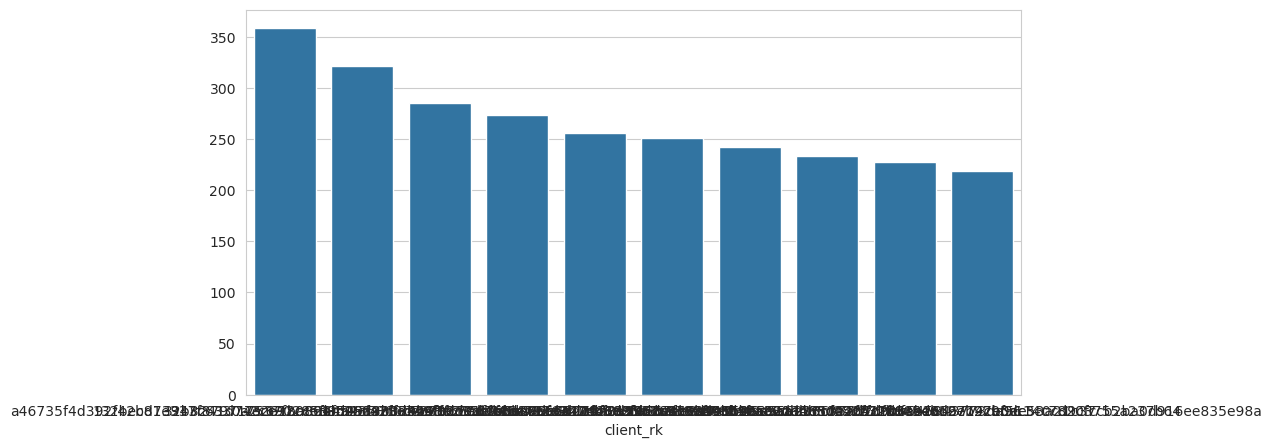

In [24]:
my_analis(df2, "client_rk")

1) Процент пустых записей: 6.74978287863454
2) Количество пустых записей: 56424
3) Количество уникальных записей: 7
4) Топ уникальных записей для order_status_cd
SUC    759950
NaN     56424
PRC     18467
ERR       650
NSH       304
CNC        84
REJ        58
Name: count, dtype: int64:
5) Количество типов записей: order_status_cd
<class 'str'>      779514
<class 'float'>     56424
Name: count, dtype: int64


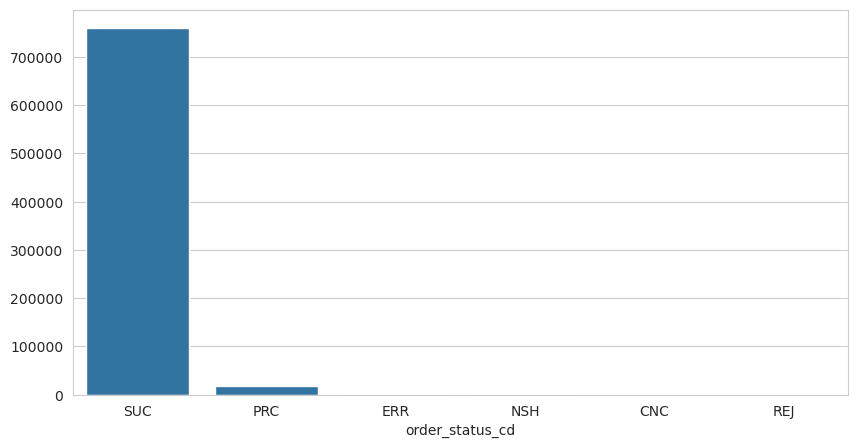

In [25]:
my_analis(df2, "order_status_cd")